# Evidence and Model Selection

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/salihyesil59/CosmoFit/blob/dev/examples/04-inference/evidence_and_model_selection.ipynb)

A new model almost always fits better than the one it generalizes —
it contains it. The question is whether the improvement is worth the
parameter, and there are three levels of answer:

| tool | asks | needs |
|---|---|---|
| **AIC / BIC** | is Δχ² large for the parameters spent? | a best fit |
| **likelihood-ratio test** | is Δχ² larger than chance? | *nested* models |
| **Bayesian evidence** | does the data prefer the model, integrated over its prior? | a nested-sampling run |

They do not always agree, and this notebook shows a case where they
don't — which is the interesting part.

Bayesian evidence needs `dynesty`, an optional extra.

## Setup

In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists("CosmoFit"):
        !git clone --quiet -b dev https://github.com/salihyesil59/CosmoFit.git
    %cd CosmoFit
    !pip install -q -e ".[evidence]"

    # The editable install runs in a subprocess, so this already-running
    # kernel does not see the .pth it writes -- and `import CosmoFit`
    # would resolve to the bare checkout directory instead (same name,
    # and /content is on sys.path). Point sys.path at src/ directly.
    import importlib
    sys.path.insert(0, os.path.abspath("src"))
    importlib.invalidate_caches()
else:
    print("Not running in Colab -- assuming CosmoFit is already installed "
          "(pip install -e \".[evidence]\" from the repository root).")

Not running in Colab -- assuming CosmoFit is already installed (pip install -e ".[evidence]" from the repository root).


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from CosmoFit import Fitter
from CosmoFit.cosmology.models import LCDM, WCDM
from CosmoFit.stats.evidence import bayes_factor, interpret
from CosmoFit.stats.model_comparison import aic, bic, likelihood_ratio_test

plt.rcParams["figure.dpi"] = 110

## 1. Two nested models

`wCDM` is ΛCDM with the dark-energy equation of state freed:
`w0 = -1` recovers ΛCDM exactly, so the two are nested and every
tool applies.

In [3]:
DATASETS = ["cc", "desi", "pantheon"]
COMMON = {"H0": 70.0, "Omega_m": 0.3, "rd": 147.0}

lcdm = Fitter(
    model=LCDM, datasets=DATASETS,
    free_params=["H0", "Omega_m", "rd"],
    initial=COMMON,
)
lcdm_best = lcdm.best_fit(restarts=3, seed=0)

wcdm = Fitter(
    model=WCDM, datasets=DATASETS,
    free_params=["H0", "Omega_m", "w0", "rd"],
    initial={**COMMON, "w0": -1.0},
    bounds={"w0": (-2.0, -0.3)},
)
wcdm_best = wcdm.best_fit(restarts=3, seed=0)

print(f"LCDM  chi2 = {lcdm_best.fun:8.3f}  ({len(lcdm.free_params)} parameters)")
print(f"wCDM  chi2 = {wcdm_best.fun:8.3f}  ({len(wcdm.free_params)} parameters)")
print(f"\ndelta chi2 = {lcdm_best.fun - wcdm_best.fun:+.3f}")
print("w0 =", round(dict(zip(wcdm.free_params, wcdm_best.x))["w0"], 4))

LCDM  chi2 = 1485.196  (3 parameters)
wCDM  chi2 = 1481.740  (4 parameters)
delta chi2 = +3.456
w0 = -0.908


## 2. Information criteria

AIC penalizes each parameter by 2; BIC by `ln(n_data)`, which for a
thousand-point dataset is nearly 7 — so BIC is much harsher on extra
freedom, and the two can disagree.

In [4]:
n_data = lcdm.n_data
rows = [("LCDM", lcdm_best.fun, len(lcdm.free_params)),
        ("wCDM", wcdm_best.fun, len(wcdm.free_params))]

print(f"{'model':>6s} {'chi2':>9s} {'k':>3s} {'AIC':>9s} {'BIC':>9s}")
for name, chi2, k in rows:
    print(f"{name:>6s} {chi2:9.3f} {k:3d} {aic(chi2, k):9.3f} "
          f"{bic(chi2, k, n_data):9.3f}")

d_aic = aic(*rows[0][1:]) - aic(*rows[1][1:])
d_bic = bic(rows[0][1], rows[0][2], n_data) - bic(rows[1][1], rows[1][2], n_data)
print(f"\ndelta_AIC = {d_aic:+.3f}    delta_BIC = {d_bic:+.3f}")
print(f"(positive favours wCDM; {n_data} data points, ln n = {np.log(n_data):.2f})")

 model      chi2   k       AIC       BIC
  LCDM  1485.196   3  1491.196  1507.454
  wCDM  1481.740   4  1489.740  1511.417
delta_AIC = +1.456    delta_BIC = -3.963
(positive favours wCDM; 1668 data points, ln n = 7.42)


## 3. The likelihood-ratio test

Valid **only** between nested models, and only where the special
value is not on the boundary of the parameter space. Both hold
here.

In [5]:
lrt = likelihood_ratio_test(
    chi2_null=lcdm_best.fun, k_null=len(lcdm.free_params),
    chi2_alt=wcdm_best.fun, k_alt=len(wcdm.free_params),
)
for key, value in lrt.items():
    print(f"  {key:12s} = {value}")

  delta_chi2   = 3.4563685406958484
  delta_k      = 1
  p_value      = 0.06300855442295421
  sigma        = 1.5299984651384033


### When it does not apply

Two situations this library runs into often:

- **`LsCDM`** reaches ΛCDM only as `z† → ∞`. There is no parameter
  value that *is* ΛCDM, so the models are not nested in the sense
  the test requires.
- **`DGP`** is not nested in ΛCDM at all — it is a different theory,
  not a generalization.

In both cases the χ² difference has no reference distribution, and
the answer has to come from the evidence.

## 4. Bayesian evidence

Nested sampling integrates the posterior over the prior, giving

$$Z = \int \mathcal{{L}}(\theta)\,\pi(\theta)\,d\theta ,$$

which automatically penalizes a model whose prior volume is mostly
wasted — the Occam factor. No nesting is required, and no
asymptotic distribution is assumed.

It is *much* more expensive than a best fit: tens of thousands of
likelihood evaluations rather than hundreds.

In [6]:
lcdm_nested = lcdm.run_nested(n_live=400, dlogz=0.1, seed=0, progress=True)
print(lcdm_nested)

0it [00:00, ?it/s]


  9%|▉         | 77/832 [00:00<00:00, 761.93it/s, bound: 0 | nc: 1 | ncall: 485 | eff(%): 15.876 | loglstar: -3232.032 | logz: -3238.255 +/-  0.121 | dlogz: 2493.904 >  0.100]


 12%|█▏        | 154/1248 [00:00<00:01, 636.51it/s, bound: 0 | nc: 5 | ncall: 610 | eff(%): 25.246 | loglstar: -1979.315 | logz: -1986.332 +/-  0.130 | dlogz: 1243.938 >  0.100]


 14%|█▍        | 219/1562 [00:00<00:02, 567.78it/s, bound: 0 | nc: 1 | ncall: 728 | eff(%): 30.082 | loglstar: -1618.155 | logz: -1625.342 +/-  0.132 | dlogz: 885.619 >  0.100] 


 12%|█▏        | 277/2313 [00:00<00:03, 538.21it/s, bound: 0 | nc: 1 | ncall: 846 | eff(%): 32.742 | loglstar: -1357.038 | logz: -1364.397 +/-  0.135 | dlogz: 625.164 >  0.100]


...

 97%|█████████▋| 3937/4052 [00:18<00:00, 443.60it/s, bound: 16 | nc: 2 | ncall: 20962 | eff(%): 18.782 | loglstar: -742.893 | logz: -750.486 +/-  0.125 | dlogz:  0.134 >  0.100]


 98%|█████████▊| 3985/4052 [00:19<00:00, 349.54it/s, bound: 17 | nc: 1 | ncall: 21049 | eff(%): 18.932 | loglstar: -742.868 | logz: -750.474 +/-  0.125 | dlogz:  0.119 >  0.100]


100%|█████████▉| 4035/4053 [00:19<00:00, 381.88it/s, bound: 17 | nc: 3 | ncall: 21134 | eff(%): 19.092 | loglstar: -742.847 | logz: -750.463 +/-  0.125 | dlogz:  0.105 >  0.100]


100%|█████████▉| 4052/4053 [00:19<00:00, 208.92it/s, +400 | bound: 17 | nc: 1 | ncall: 21567 | eff(%): 21.033 | loglstar: -742.595 | logz: -750.372 +/-  0.127 | dlogz:  0.000 >  0.100]


NestedResult(ln Z = -750.372 +- 0.157, 4452 samples, 21167 evaluations)


In [7]:
wcdm_nested = wcdm.run_nested(n_live=400, dlogz=0.1, seed=0, progress=True)
print(wcdm_nested)

0it [00:00, ?it/s]


  8%|▊         | 70/900 [00:00<00:01, 699.35it/s, bound: 0 | nc: 1 | ncall: 482 | eff(%): 14.523 | loglstar: -4163.076 | logz: -4169.935 +/-  0.131 | dlogz: 3464.285 >  0.100]


 14%|█▎        | 140/1032 [00:00<00:01, 670.66it/s, bound: 0 | nc: 1 | ncall: 582 | eff(%): 24.055 | loglstar: -2535.945 | logz: -2542.979 +/-  0.133 | dlogz: 1833.673 >  0.100]


  9%|▊         | 208/2399 [00:00<00:03, 624.08it/s, bound: 0 | nc: 2 | ncall: 690 | eff(%): 30.145 | loglstar: -1861.351 | logz: -1868.257 +/-  0.127 | dlogz: 1122.873 >  0.100]


 11%|█         | 273/2463 [00:00<00:03, 632.69it/s, bound: 0 | nc: 4 | ncall: 799 | eff(%): 34.168 | loglstar: -1600.337 | logz: -1607.391 +/-  0.127 | dlogz: 861.560 >  0.100] 


...

 98%|█████████▊| 4956/5070 [00:26<00:00, 256.38it/s, bound: 32 | nc: 1 | ncall: 26276 | eff(%): 18.861 | loglstar: -741.373 | logz: -751.295 +/-  0.143 | dlogz:  0.134 >  0.100]


 98%|█████████▊| 4992/5070 [00:26<00:00, 277.66it/s, bound: 32 | nc: 2 | ncall: 26375 | eff(%): 18.927 | loglstar: -741.349 | logz: -751.288 +/-  0.144 | dlogz:  0.122 >  0.100]


 99%|█████████▉| 5037/5070 [00:26<00:00, 316.25it/s, bound: 32 | nc: 6 | ncall: 26477 | eff(%): 19.024 | loglstar: -741.321 | logz: -751.279 +/-  0.144 | dlogz:  0.109 >  0.100]


100%|█████████▉| 5069/5070 [00:26<00:00, 191.75it/s, +400 | bound: 32 | nc: 1 | ncall: 26961 | eff(%): 20.590 | loglstar: -740.869 | logz: -751.198 +/-  0.148 | dlogz:  0.000 >  0.100]


NestedResult(ln Z = -751.198 +- 0.179, 5469 samples, 26561 evaluations)


In [8]:
result = bayes_factor(alt=wcdm_nested, null=lcdm_nested)
for key, value in result.items():
    print(f"  {key:20s} = {value}")

  ln_B                 = -0.8257083293485721
  ln_B_error           = 0.23793615747835772
  interpretation       = inconclusive
  favours              = null
  prior_volume_alt     = 1530.0
  prior_volume_null    = 900.0


### The three tools have now disagreed

Worth stopping on, because this was not staged:

- **Δχ² = 3.5** for one parameter, `p = 0.063`, `1.5 sigma` — a
  mild preference for `wCDM`.
- **ΔAIC is positive** (favours `wCDM`), **ΔBIC is negative**
  (favours ΛCDM). With 1668 data points `ln n = 7.4`, so BIC
  charges more than twice what AIC does for the same parameter.
- **ln B is negative**: integrated over its prior, the *evidence*
  prefers ΛCDM — the opposite direction from Δχ².

Nothing is wrong with any of them. They are answering different
questions, and the Bayes factor is the only one that accounts for
`w0` having a prior most of which the data reject. Which is the
right answer depends on the question, and quoting only the one
that agrees with you is the failure mode all three exist to
prevent.

`interpret()` is the Kass & Raftery scale — `|ln B| < 1` is "not
worth more than a bare mention", up to `> 5` for "very strong".

In [9]:
for ln_b in (0.3, 1.5, 3.5, 6.0):
    print(f"  ln B = {ln_b:+.1f}  ->  {interpret(ln_b)}")

  ln B = +0.3  ->  inconclusive
  ln B = +1.5  ->  positive
  ln B = +3.5  ->  strong
  ln B = +6.0  ->  very strong


## 5. The evidence depends on the prior, and that is not a bug

A Bayes factor computed against uniform priors is a statement about
those priors as much as about the models: widen `w0`'s range and
wCDM's evidence falls, because more of its prior volume is doing
nothing.

This is worth **measuring** rather than worrying about in the
abstract.

In [10]:
widths = [(-1.5, -0.5), (-2.0, -0.3), (-3.0, 0.0)]
print(f"{'w0 prior':>16s} {'volume':>9s} {'ln Z':>10s} {'ln B':>9s}")

for low, high in widths:
    f = Fitter(
        model=WCDM, datasets=DATASETS,
        free_params=["H0", "Omega_m", "w0", "rd"],
        initial={**COMMON, "w0": -1.0},
        bounds={"w0": (low, high)},
    )
    run = f.run_nested(n_live=400, dlogz=0.1, seed=0, progress=False)
    ln_b = run.log_evidence - lcdm_nested.log_evidence
    print(f"  ({low:+.1f}, {high:+.1f})  {high - low:9.1f} "
          f"{run.log_evidence:10.3f} {ln_b:+9.3f}")

print("\nWidening the prior costs the model evidence with the data")
print("unchanged. Always quote the prior alongside a Bayes factor.")

        w0 prior    volume       ln Z      ln B


  (-1.5, -0.5)        1.0   -750.844    -0.472


  (-2.0, -0.3)        1.7   -751.198    -0.826


  (-3.0, +0.0)        3.0   -751.732    -1.359
Widening the prior costs the model evidence with the data
unchanged. Always quote the prior alongside a Bayes factor.


## 6. Where the three tools disagree

The clearest case in this library is **ΛsCDM** — a cosmological
constant that switches sign at `z†`. Its Δχ² over ΛCDM is 5.40,
which looks like real evidence. Its Bayes factor is
**ln B = +0.494 ± 0.319: inconclusive**.

The reason is visible in the posterior: `z†`'s 95% interval runs to
`[2.5, 96.6]`, so most of its prior volume does nothing, and the
Occam factor eats the improvement. Narrowing `z†` to `(0.5, 10)`
takes ln B to +1.158 — the same data, a different prior, a different
verdict.

That analysis is in
[`../05-case-studies/lscdm_mcmc.ipynb`](../05-case-studies/lscdm_mcmc.ipynb),
and how much of it is a choice is audited across 20 dataset
combinations in
[`../05-case-studies/dark_energy_evidence_audit.ipynb`](../05-case-studies/dark_energy_evidence_audit.ipynb).

## 7. Posterior samples come free

Nested sampling returns samples as well as the evidence, so a run
can be read like an MCMC.

In [11]:
summary = wcdm_nested.summary()
for name, stats in summary.items():
    print(f"  {name:8s} = {stats['median']: .4f} "
          f"-{stats['minus']:.4f} +{stats['plus']:.4f}")

  H0       =  68.3157 -3.1515 +3.2714
  Omega_m  =  0.2960 -0.0139 +0.0137
  w0       = -0.9098 -0.0523 +0.0457
  rd       =  146.4033 -6.6935 +6.7717


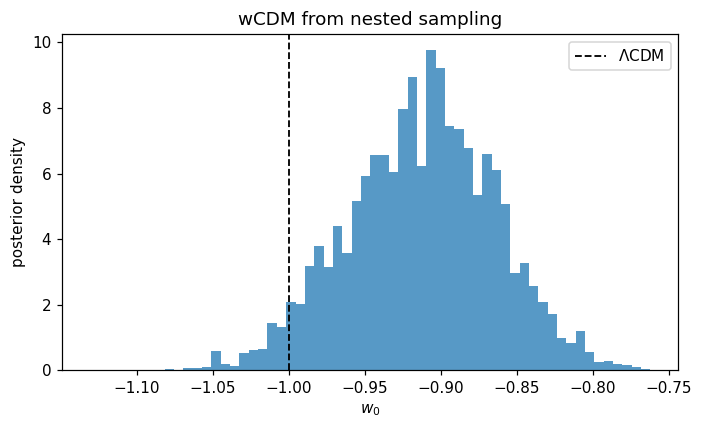

In [12]:
index = wcdm_nested.free_params.index("w0")
w0_samples = wcdm_nested.samples[:, index]

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(w0_samples, bins=60, density=True, alpha=0.75,
        color="tab:blue", edgecolor="none")
ax.axvline(-1.0, color="k", lw=1.2, ls="--", label=r"$\Lambda$CDM")
ax.set_xlabel("$w_0$")
ax.set_ylabel("posterior density")
ax.set_title("wCDM from nested sampling")
ax.legend()
fig.tight_layout()

## Summary

- **AIC/BIC** are cheap and need only a best fit, but the penalty is
  a rule of thumb, not a probability.
- **The likelihood-ratio test** is exact asymptotically, but only
  between nested models away from a boundary.
- **The evidence** applies to any two models, and is the only one of
  the three that can compare `DGP` against ΛCDM at all — at the cost
  of depending on the prior, which has to be quoted.

Next:
[`profile_likelihood_and_fisher.ipynb`](profile_likelihood_and_fisher.ipynb)
for what to do when a parameter sits *on* a boundary, and
[`tension_statistics.ipynb`](tension_statistics.ipynb) for comparing
datasets rather than models.